In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("AIML Dataset.csv")


In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
data['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [8]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
data.shape

(6362620, 11)

In [10]:
### % of frauds in total data

(data['isFraud'].value_counts()[1] / data.shape[0]) * 100

np.float64(0.12908204481801522)

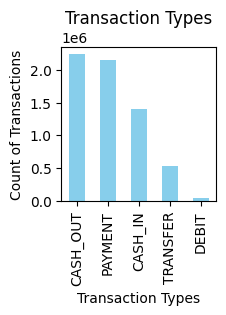

In [11]:
# Plotting the type of transactions
plt.figure(figsize=(2,2))
data['type'].value_counts().plot(kind='bar', title='Transaction Types', color='skyblue')
plt.xlabel("Transaction Types")
plt.ylabel("Count of Transactions")
plt.show()

In [12]:
# Plotting No of frauds of each type

In [13]:
fraud_by_type = data.groupby('type')['isFraud'].mean().sort_values(ascending=False)

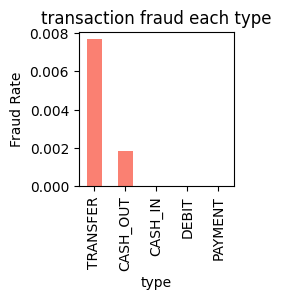

In [14]:
plt.figure(figsize=(2,2))

fraud_by_type.plot(kind='bar', title='transaction fraud each type', color='salmon')
plt.ylabel('Fraud Rate')
plt.show()

In [15]:
### AMOUNT COLUMN STATISTICS CHECK

In [16]:
data['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

In [17]:
# here above
# 50 % = median = 74871
# mean = 179861
# mean > median => data is right skewd
# std = 603858 -> very high means data is highly spread out
# 75 % =>208721 and max => 9245516 -> very huge gap means there can be outlier or rare payments

In [18]:
# plotting histogram of data['amount'] but values are big 
# we want smooth and small graph so we do tranformation 

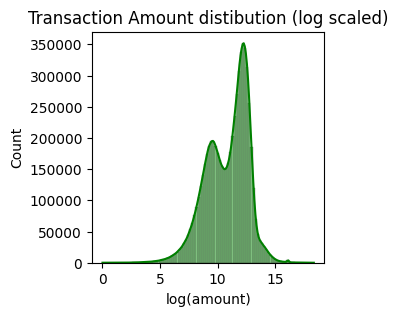

In [19]:
plt.figure(figsize=(3,3))

sns.histplot(np.log1p(data['amount']), bins=100, kde=True, color='green')
plt.title('Transaction Amount distibution (log scaled)')
plt.xlabel('log(amount)')
plt.show()

In [20]:
# Now plotting Boxplot of amount vs isFraud

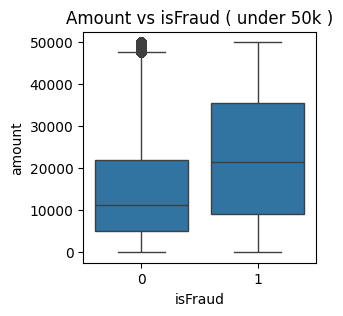

In [21]:
plt.figure(figsize=(3,3))
sns.boxplot(data=data[data['amount'] < 50000], x = 'isFraud', y = 'amount')
plt.title('Amount vs isFraud ( under 50k )')
plt.show()

In [22]:
# what we analyse from Box Plot above :-

# fraud transactions are generally larger in amount 
# median (non fraud trans) = 10k-12k
# median (fraud trans) = 21k aprox

# Box height of fraud transactions is big means higher spread, they are less consistent

# box height of non fraud are small , means normal transaction amount are more predictable and
# they have outlier as well

In [23]:
# Now checking balance chains and anamolies

In [24]:
data['balanceDiffOrig'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['balanceDiffDest'] = data['newbalanceDest'] - data['oldbalanceDest']

In [25]:
(data['balanceDiffDest'] < 0).sum()

np.int64(1238864)

In [26]:
# Here step column is increading day by day
# plot fraud _per_step 

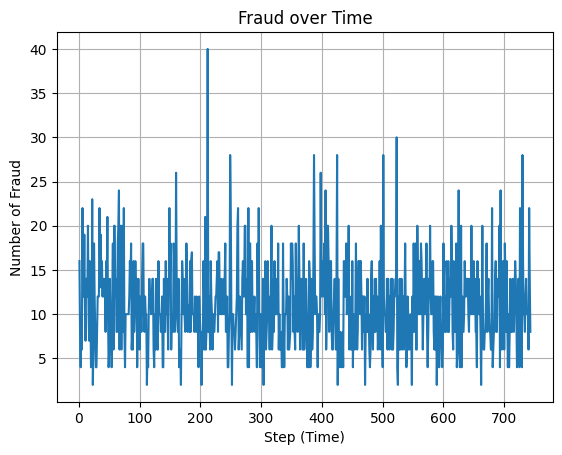

In [27]:


fraud_per_step = data[data['isFraud'] ==1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, label='Fraud per Step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Fraud')
plt.title('Fraud over Time')
plt.grid(True)
plt.show()

In [28]:
data.drop(columns='step', inplace=True)

In [29]:
data.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [30]:
# Customer Wise Analysis

In [31]:
# Finding customers which make higher amount of transactions like top senders or receivers

In [32]:
data['nameOrig'].value_counts().head(10)

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [33]:
# top 10 Receivers

data['nameDest'].value_counts().head(10)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [34]:
# find top 10 fraud enders 

fraud_users = data[data['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [35]:
fraud_users

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64

In [36]:
# Transfers and cash-out are two main types of frauds as seen above and create a dataset for this

In [37]:
fraud_types = data[data['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [38]:
fraud_types

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


In [39]:
# Creating a count plot of fraud types 

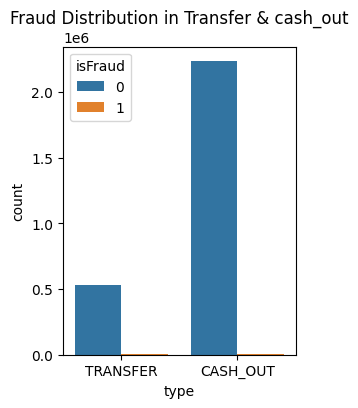

In [40]:
plt.figure(figsize=(3,4))

sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title('Fraud Distribution in Transfer & cash_out')
plt.show()

In [41]:
# in above graph it shows fraud are present but very low

In [42]:
# Now we check corr 

In [43]:
corr = data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [44]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


In [45]:
# plotting the corr matric in heatmap

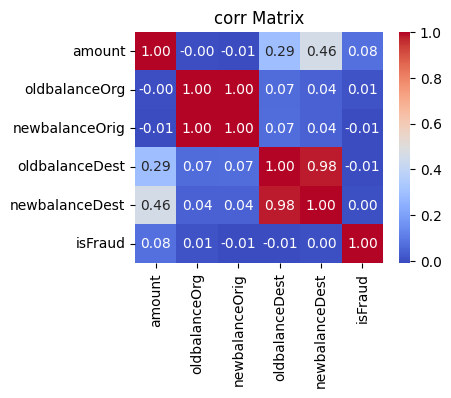

In [46]:

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("corr Matrix")
plt.show()

In [47]:
# The above correlation matrix gives values from -1 to 1 

# -1 means strong negative correlation
# +1 means strong possitive relation

In [48]:
# Dataset of Customers having zero balance after transaction AND their 
# transaction type is tranfer or cashout where most frauds are detected

# they can be normal transcations or can have fraud transaction means they are suspecious transactions

In [49]:
zero_after_transaction = data[

    (data['oldbalanceOrg'] >0) &
    (data['newbalanceOrig'] == 0) &
    (data['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [50]:
zero_after_transaction.shape

(1188074, 12)

In [51]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [52]:
# as we check the isFraud data 
# Non Fraud values - 6354407
# Fraud Vlaues - 8213

# It means data is imbalanced => non fraud dominates fraud transactions

In [53]:
# we will do feature engineering and modeling

In [54]:
from sklearn.model_selection import train_test_split   # for splitting data
from sklearn.preprocessing import StandardScaler       # for scaling
from sklearn.linear_model import LogisticRegression    # for modeling
from sklearn.metrics import classification_report, confusion_matrix  # for model evaluation
from sklearn.pipeline import Pipeline  # for training the model and doing tranform ops together
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [55]:
data.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [56]:
# now removing those columns that are not imp for modeling

In [57]:
data_model = data.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [58]:
data_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [59]:
# Now seprating categorical and numeric columns

categorical = ['type']
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [60]:
# Now seperating target and data for train test split and performing train test

In [61]:
Y = data_model['isFraud']
X = data_model.drop('isFraud', axis=1)

In [62]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, stratify=Y)

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder = 'drop'
)

In [64]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [65]:
# training the model 

In [66]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [67]:
# Now predictions using test data o check accuracy

In [68]:
y_pred = pipeline.predict(x_test)

In [69]:
# Now checking model accuracy by comparing y_pred with y_test (test data)

In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [71]:
# Analysis of Above classfication report 

# Class 0 - Non Fraud
# Recall = 0.95 means model catches 95% of non fraud data and its precision =1 means 100%

# class 1 - Fraud Transactions
# Recall = 0.93 means model catches 93% fraud falgged data but precision is 0.02 means 
# only 2% of flagged fraud data is fraud - terrible

# model is working properly

# methods to correct -
# 1. we can use another metthods of class imbalance like smooth or undersampling type of things
# 2. we can try different models 
# 3. we can change the treshold of prediction

In [72]:
# changing treshold of prediction

y_probs = pipeline.predict_proba(x_test)[:, 1]

y_pred = (y_probs > 0.9).astype(int)

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1906322
           1       0.10      0.76      0.18      2464

    accuracy                           0.99   1908786
   macro avg       0.55      0.88      0.59   1908786
weighted avg       1.00      0.99      0.99   1908786



In [74]:
# Now after increasing the treshold value precision inc but it is still low
# means logistic rgression is too simple for this bec it works like st line (linear)

# fraud detection data is-
# 1. highly imbalanced
# 2. highly Non linear
# 3. patterns are complex

In [75]:
# Trying stronger model

In [76]:
# Random forest model

In [77]:
from sklearn.ensemble import RandomForestClassifier

pipeline_random_forest = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=30,     # can take 100 but speed of pc slow so took 30 for project
        class_weight = 'balanced',
        random_state=42
    ))
])

In [78]:
# training the random_forest model

pipeline_random_forest.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [79]:
y_pred_random_forest = pipeline_random_forest.predict(x_test)

In [80]:
print(classification_report(y_pred_random_forest, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906773
           1       0.79      0.97      0.87      2013

    accuracy                           1.00   1908786
   macro avg       0.89      0.98      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786



In [81]:
# Why Random Forest worked better

# Because it:

# Handles non-linear patterns
# Captures feature interactions
# Works well with imbalanced data
# Doesn’t assume straight-line separation (unlike Logistic Regression)

In [82]:
# printing confusion matrix

In [83]:
print(confusion_matrix(y_test, y_pred_random_forest))

[[1906253      69]
 [    520    1944]]


In [84]:
pipeline_random_forest.score(x_test, y_test) * 100

99.9691426906945

In [85]:
# above accuracy score is 99% but it is sometime missleading as
# in confusion matrix it is clear that fn = 521 means
# predicted negatives but actually +ve

In [86]:
# now deployment of model

In [87]:
import joblib

In [88]:
joblib.dump(pipeline_random_forest, 'fraud_detection_pipepline.pkl')

['fraud_detection_pipepline.pkl']